In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("D:\\MIMIC_PROJECT\\ml_project\\data\\raw\\mimic_mortality.csv")

df.shape


(546028, 11)

In [10]:
df.head()

,subject_id,hadm_id,mortality_label,hgb_mean,wbc_mean,platelets_mean,creatinine_mean,sodium_mean,potassium_mean,bicarbonate_mean,glucose_mean
0,10106244,26713233,0,12.70,NaN,254.666667,0.85,137.333333,4.200000,22.500000,298.500000
1,10584718,23485217,1,7.90,NaN,72.000000,3.35,142.500000,5.400000,19.500000,123.000000
2,16119128,28780738,0,10.55,NaN,258.000000,4.70,137.333333,3.100000,19.333333,128.666667
3,11763197,28316654,0,10.10,NaN,185.000000,0.70,152.000000,3.566667,33.000000,94.000000
4,10332792,24654607,0,16.40,NaN,192.000000,1.05,129.500000,2.900000,36.000000,113.000000


In [13]:
df.info()
df.describe

<class 'pandas.DataFrame'>
RangeIndex: 546028 entries, 0 to 546027
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   subject_id        546028 non-null  int64  
 1   hadm_id           546028 non-null  int64  
 2   mortality_label   546028 non-null  int64  
 3   hgb_mean          361700 non-null  float64
 4   wbc_mean          1121 non-null    float64
 5   platelets_mean    364025 non-null  float64
 6   creatinine_mean   357541 non-null  float64
 7   sodium_mean       352239 non-null  float64
 8   potassium_mean    355561 non-null  float64
 9   bicarbonate_mean  349525 non-null  float64
 10  glucose_mean      346625 non-null  float64
dtypes: float64(8), int64(3)
memory usage: 45.8 MB


<bound method NDFrame.describe of         subject_id   hadm_id  mortality_label  hgb_mean  wbc_mean  \
0         10106244  26713233                0     12.70       NaN   
1         10584718  23485217                1      7.90       NaN   
2         16119128  28780738                0     10.55       NaN   
3         11763197  28316654                0     10.10       NaN   
4         10332792  24654607                0     16.40       NaN   
...            ...       ...              ...       ...       ...   
546023    11646406  27874185                0      7.75       NaN   
546024    15096292  22535372                0     10.90       NaN   
546025    15547667  26159797                0     11.40       NaN   
546026    12070314  21349287                0     12.50       NaN   
546027    13351097  27761831                0     13.40       NaN   

        platelets_mean  creatinine_mean  sodium_mean  potassium_mean  \
0           254.666667             0.85   137.333333        4.200

In [14]:
df['mortality_label'].value_counts(normalize=True) * 100


mortality_label
0    97.838756
1     2.161244
Name: proportion, dtype: float64

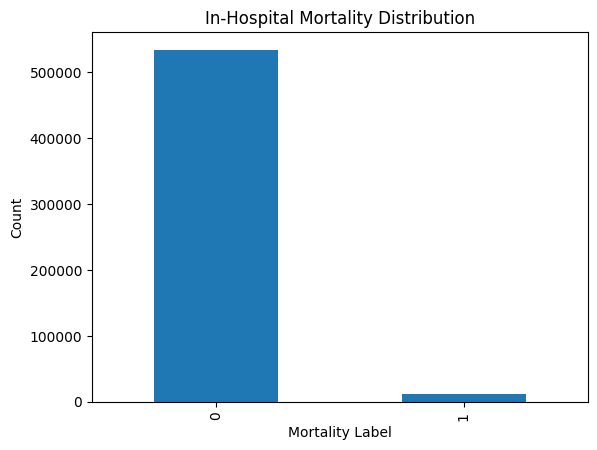

In [15]:
df['mortality_label'].value_counts().plot(kind='bar')
plt.title("In-Hospital Mortality Distribution")
plt.xlabel("Mortality Label")
plt.ylabel("Count")
plt.show()


Missing analysis 

In [16]:
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
missing_pct


wbc_mean            99.794699
glucose_mean        36.518823
bicarbonate_mean    35.987715
sodium_mean         35.490671
potassium_mean      34.882277
creatinine_mean     34.519658
hgb_mean            33.757976
platelets_mean      33.332173
mortality_label      0.000000
subject_id           0.000000
hadm_id              0.000000
dtype: float64

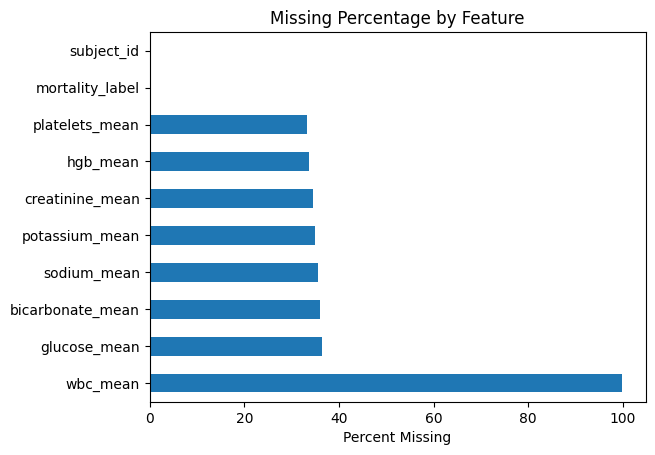

In [17]:
missing_pct.head(10).plot(kind='barh')
plt.title("Missing Percentage by Feature")
plt.xlabel("Percent Missing")
plt.show()


Feature distribution

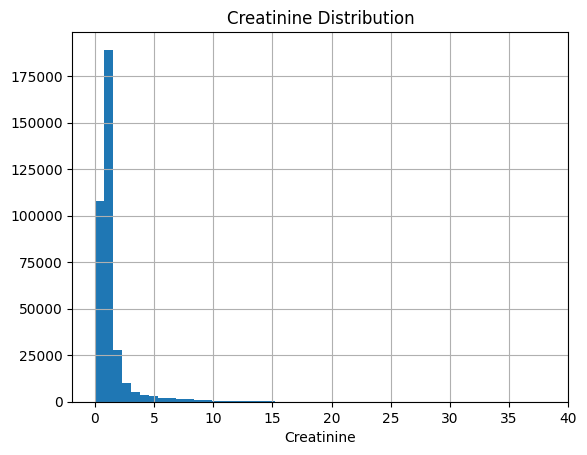

In [18]:
df['creatinine_mean'].hist(bins=50)
plt.title("Creatinine Distribution")
plt.xlabel("Creatinine")
plt.show()


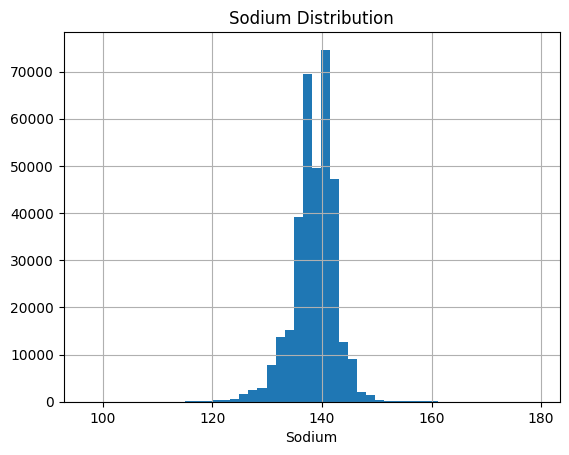

In [19]:
df['sodium_mean'].hist(bins=50)
plt.title("Sodium Distribution")
plt.xlabel("Sodium")
plt.show()


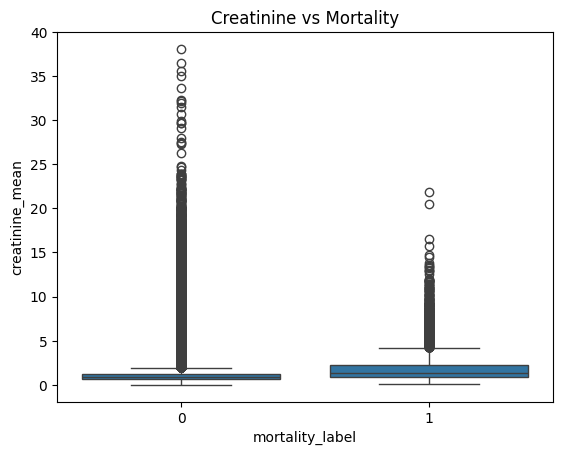

In [20]:
sns.boxplot(
    x='mortality_label',
    y='creatinine_mean',
    data=df
)
plt.title("Creatinine vs Mortality")
plt.show()


higher creatinine → higher mortality

lower bicarbonate → higher mortality

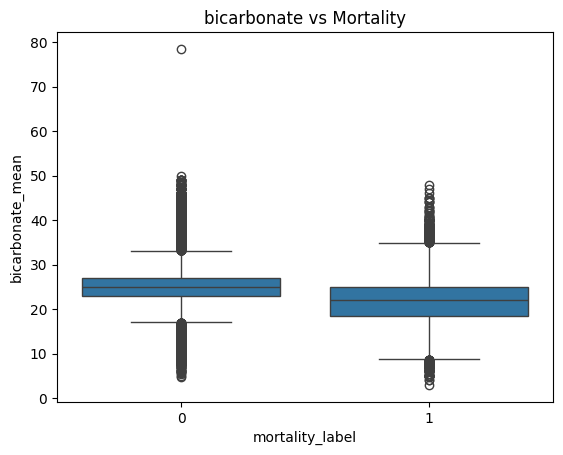

In [24]:
sns.boxplot(
    x='mortality_label',
    y='bicarbonate_mean',
    data=df
)
plt.title("bicarbonate vs Mortality")
plt.show()


Mortality rate is imbalanced (~10%), reflecting real-world conditions

Significant missingness exists, likely due to clinician-driven lab ordering

Patients with higher creatinine and lower bicarbonate show higher mortality risk

Early laboratory values provide meaningful signal for outcome prediction